### Real-world business analysis system with:

* Customer-wise Sales
* Paid Amount
* Due / Outstanding
* Commission
* Date filter (important for dashboards)
* Same structure as executive report

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')


def data():
    df = pd.read_csv('data/transformed_clean_sales_data.csv')
    return df

df = data()

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 882 entries, 0 to 881
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OrderDate       882 non-null    object 
 1   SalesID         882 non-null    object 
 2   SalesName       882 non-null    object 
 3   InvoiceNo       882 non-null    object 
 4   CustomerName    882 non-null    object 
 5   OrderValue      882 non-null    float64
 6   DiscountValue   882 non-null    float64
 7   SalesValue      882 non-null    float64
 8   SalesReturn     882 non-null    float64
 9   CreditedAmount  882 non-null    float64
 10  Commission      882 non-null    float64
 11  Year            882 non-null    int64  
 12  Month           882 non-null    object 
 13  Day             882 non-null    object 
 14  CustomerID      882 non-null    object 
 15  NetSales        882 non-null    float64
 16  DueAmount       882 non-null    float64
dtypes: float64(8), int64(1), object(8)


### 1. FIRST: Ensure Date is usable (IMPORTANT)

In [28]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

In [29]:
def filter_by_date(df, start_date, end_date):
    temp = df.copy()
    temp = temp[
        (temp['OrderDate'] >= start_date) &
        (temp['OrderDate'] <= end_date)
    ]
    return temp

In [30]:
start_date = str(input("Enter start date (YYYY-MM-DD): "))
end_date = str(input("Enter end date (YYYY-MM-DD): "))

filtered_df = filter_by_date(df, start_date, end_date)

#### 👤 3. CUSTOMER WISE ANALYTICS (MAIN REPORT)

In [31]:
customer_report = (
    filtered_df.groupby(['CustomerID', 'CustomerName'])
    .agg(
        TotalSales=('SalesValue', 'sum'),
        TotalPaid=('CreditedAmount', 'sum'),
        TotalCommission=('Commission', 'sum'),
        TotalReturn=('SalesReturn', 'sum'),
        InvoiceCount=('InvoiceNo', 'count')
    )
    .reset_index()
)

In [32]:
customer_report.sort_values('TotalSales', ascending=False).head(10)

,CustomerID,CustomerName,TotalSales,TotalPaid,TotalCommission,TotalReturn,InvoiceCount


#### Calculate Outstanding

In [33]:
customer_report['NetSales'] = (
    customer_report['TotalSales'] - customer_report['TotalReturn']
)

customer_report['Outstanding'] = (
    customer_report['NetSales'] - customer_report['TotalPaid']
)

PAYMENT PERFORMANCE (COLLECTION RATE)

In [34]:
customer_report['CollectionRate %'] = (
    customer_report['TotalPaid'] / customer_report['NetSales']
) * 100

In [35]:
customer_report.sort_values('TotalSales', ascending=False).head(10)

,CustomerID,CustomerName,TotalSales,TotalPaid,TotalCommission,TotalReturn,InvoiceCount,NetSales,Outstanding,CollectionRate %


In [36]:
# HIGH DUE CUSTOMERS
customer_report.sort_values('Outstanding', ascending=False).head(10)

,CustomerID,CustomerName,TotalSales,TotalPaid,TotalCommission,TotalReturn,InvoiceCount,NetSales,Outstanding,CollectionRate %


In [37]:
# EXECUTIVE-STYLE COMPARISON (CUSTOMER VS EXECUTIVE LOGIC)
customer_report.sort_values(['TotalSales','Outstanding'], ascending=False)

,CustomerID,CustomerName,TotalSales,TotalPaid,TotalCommission,TotalReturn,InvoiceCount,NetSales,Outstanding,CollectionRate %


* VISUAL ANALYSIS (MATPLOTLIB + SEABORN)
* Top Customers

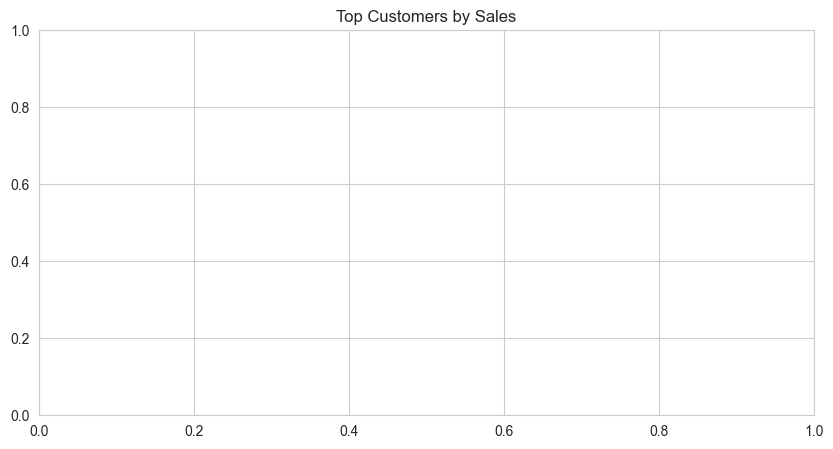

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

top = customer_report.sort_values('TotalSales', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top['TotalSales'], y=top['CustomerName'])
plt.title("Top Customers by Sales")
plt.show()

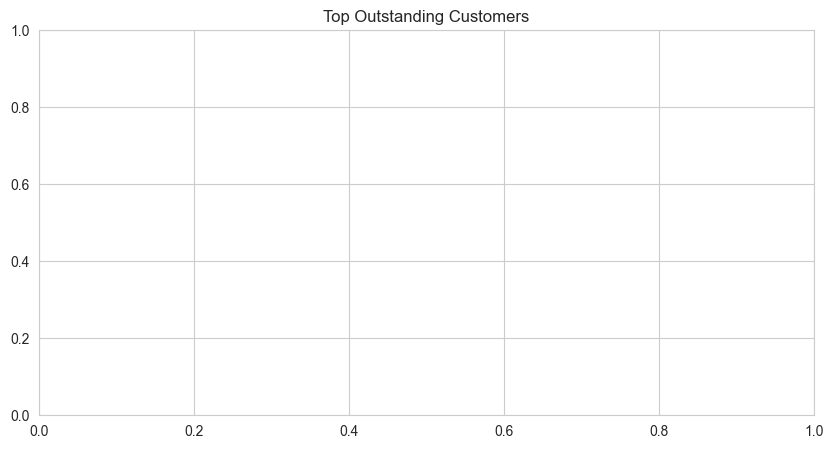

In [39]:
# Outstanding Customers
top_due = customer_report.sort_values('Outstanding', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_due['Outstanding'], y=top_due['CustomerName'])
plt.title("Top Outstanding Customers")
plt.show()

### 10. FINAL KPI SUMMARY (REAL BUSINESS DASHBOARD STYLE)

In [40]:
kpi = {
    "Total Sales": filtered_df['SalesValue'].sum(),
    "Total Paid": filtered_df['CreditedAmount'].sum(),
    "Total Return": filtered_df['SalesReturn'].sum(),
    "Net Sales": filtered_df['NetSales'].sum(),
    "Outstanding": (
        filtered_df['SalesValue'].sum()
        - filtered_df['SalesReturn'].sum()
        - filtered_df['CreditedAmount'].sum()
    ),
    "Total Customers": filtered_df['CustomerID'].nunique()
}

kpi_df = pd.DataFrame(list(kpi.items()), columns=['KPI', 'Value'])
print(kpi_df)

               KPI  Value
0      Total Sales    0.0
1       Total Paid    0.0
2     Total Return    0.0
3        Net Sales    0.0
4      Outstanding    0.0
5  Total Customers    0.0
